# Decision Tree
- Dataset: 
    1. Titanic https://www.kaggle.com/datasets/yasserh/titanic-dataset
    2. Wine https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
    3. Breast Cancer https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
- Code help from 
    - https://www.kaggle.com/code/prashant111/decision-tree-classifier-tutorial
    - https://www.geeksforgeeks.org/machine-learning/building-and-implementing-decision-tree-classifiers-with-scikit-learn-a-comprehensive-guide/

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def build_and_evaluate_tree(file_path, target_col, cols_to_drop=None, tree_params=None):
    #load dataset
    df = pd.read_csv(file_path)
    
    #drop unnecessary columns (like IDs, Names, etc.)
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop, errors='ignore')
        
    #features (X) and target (y)
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    #identify categorical and numerical columns
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns
    
    #preprocessing steps for numerical data
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])
    
    #preprocessing steps for categorical data
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    
    #combine both transformers into a single ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    #define default tree parameters if none are provided
    if tree_params is None:
        tree_params = {
    'criterion': 'gini',
    'max_depth': 10,
    'random_state': 42}
        
    #build final pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(**tree_params))
    ])
    
    print(y.value_counts()) #checking class imbalance
    
    #split data - train/test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    #training
    pipeline.fit(X_train, y_train)
    
    #predict + evaluate
    y_preds = pipeline.predict(X_test)
    
    print(f"--- Model Evaluation for {file_path} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_preds):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_preds, zero_division=0))

    #Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_preds, cmap='Blues')
    plt.title(f"Confusion Matrix: {file_path}")
    plt.show()
    
    return pipeline, X_train, X_test, y_train, y_test

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64
--- Model Evaluation for WineQT.csv ---
Accuracy: 0.6239

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.50      0.20      0.29        10
           5       0.67      0.74      0.70       145
           6       0.62      0.62      0.62       138
           7       0.51      0.44      0.47        43
           8       0.00      0.00      0.00         5

    accuracy                           0.62       343
   macro avg       0.38      0.33      0.35       343
weighted avg       0.61      0.62      0.61       343



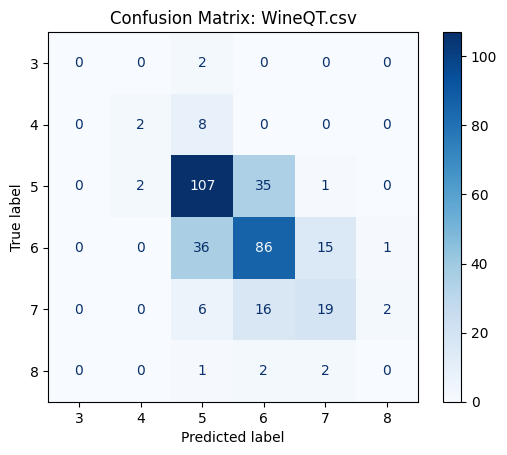

In [6]:
#run on Wine dataset
decisiontree_pipeline, X_train, X_test, y_train, y_test = build_and_evaluate_tree(
    file_path='WineQT.csv', 
    target_col='quality',        #target column name
    cols_to_drop=['Id']          #col to drop
)

using entropy:

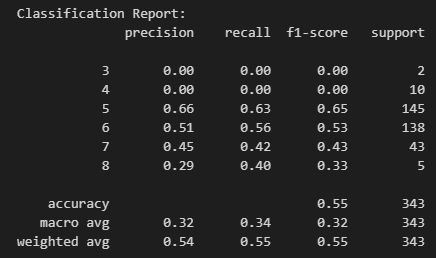

using gini:

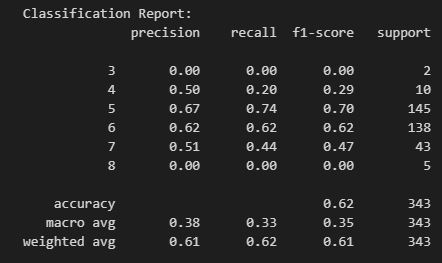

## Titanic Dataset:

Survived
0    549
1    342
Name: count, dtype: int64
--- Model Evaluation for Titanic-Dataset.csv ---
Accuracy: 0.7687

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       165
           1       0.72      0.65      0.68       103

    accuracy                           0.77       268
   macro avg       0.76      0.75      0.75       268
weighted avg       0.77      0.77      0.77       268



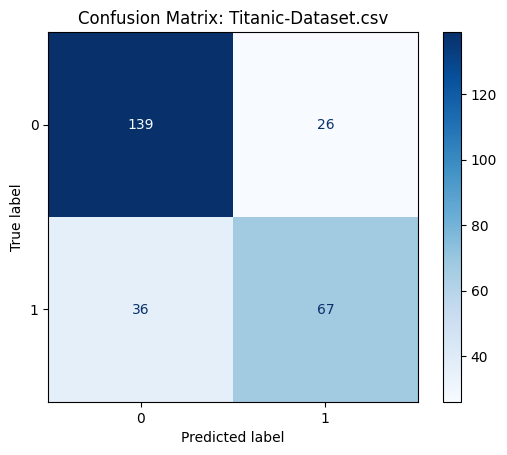

In [3]:
#run on dataset
decisiontree_pipeline, X_train, X_test, y_train, y_test = build_and_evaluate_tree(
    file_path='Titanic-Dataset.csv', 
    target_col='Survived', #target column name
    cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin'] #col to drop
)

## Breast Cancer Dataset

diagnosis
B    357
M    212
Name: count, dtype: int64
--- Model Evaluation for BreastCancer.csv ---
Accuracy: 0.9006

Classification Report:
              precision    recall  f1-score   support

           B       0.91      0.93      0.92       107
           M       0.89      0.84      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



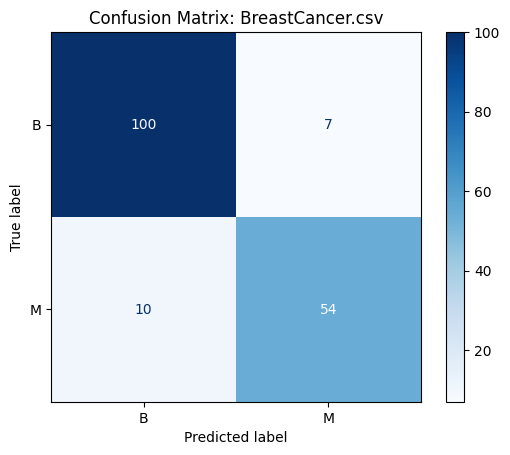

In [4]:
breast_pipeline, X_train, X_test, y_train, y_test = build_and_evaluate_tree(
    file_path='BreastCancer.csv',
    target_col='diagnosis',
    cols_to_drop=['id', 'Unnamed: 32']
)

- Notes:
    - Decision Tree doesnt need scaling